# **Lab 4.1 Data Augmentation with PyTorch**

In [1]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset
from torch.nn import functional as F
import random
import cv2
import numpy as np
from skimage.util import random_noise
import matplotlib.pyplot as plt
import os
from collections import Counter
from mpl_toolkits.axes_grid1 import ImageGrid
import zipfile
from PIL import Image

Complete the `load_data()` function that loads the image using `ImageFolder()` with the specific `transforms.compose()` provided below.
`load_data()` will return DataLoader() and print the information about the Dataset.

`transforms.Compose()` :
- `transforms.Resize()`
- `transforms.ToTensor()`
- `transforms.Pad()`
- `transforms.RandomAffine(degrees=45, translate=(0.1, 0.1),scale=(0.8, 1.2), shear=45)`
- `transforms.CenterCrop()`

Resource : [`transforms.Compose()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html#compose), [`torchvision.transforms v1`](<https://pytorch.org/vision/stable/transforms.html#v1-api-reference:~:text=custom)%20tv_tensor%20type.-,V1%20API%20Reference,-Geometry>), [`ImageFolder`](https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html), [`Dataloader`](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#:~:text=Preparing%20your%20data%20for%20training%20with%20DataLoaders)

In [2]:
def load_data(path):
    ### START CODE HERE ###
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Pad(15),
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=15),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ])

    dataset = ImageFolder(root=path, transform=transform)

    class_map = dataset.class_to_idx #{'battleship': 0, 'patrol boat': 1, 'submarine': 2}
    print("Class Map :", class_map)
    targets = dataset.targets  #[0, 0, 1, 2, 1, ...]
    print("Targets :", targets)
    class_counts = Counter(targets)
    print("Class Count :", class_counts)
    idx_to_class = {v: k for k, v in class_map.items()}
    print("Index to Class :", idx_to_class)

    data_loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)

    print("Train Dataset")
    # for label in sorted(idx_to_class.keys()):
    #     print("Label :", label)
    #     class_name = idx_to_class[label]
    #     count = class_counts[label]
    #     print(f"\tNumber of images in class {class_name}: {count}")
    # print(f"\tNumber of samples: {len(dataset)}")
    for label, idx in class_map.items() :
        count = class_counts[idx]
        print(f"\tNumber of images in class {label}: {count}")

    images, labels = next(iter(data_loader))

    fig = plt.figure(figsize=(20, 20))
    plt.style.use('dark_background')

    grid = ImageGrid(fig, 111,
                    nrows_ncols=(4, 4),  
                    axes_pad=0.5,  
                    )

    for ax, im, lb in zip(grid, images, labels):
        im_np = im.permute(1, 2, 0).numpy()
        ax.axis('off')
        ax.set_title(f"{lb.item()} : {idx_to_class[lb.item()]}")
        ax.imshow(im_np)

    plt.show()

    return data_loader

    ### END CODE HERE ###

Use your load_data() function to load the dataset in the cell below. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

```
📃Train Dataset:
	Number of images in class battleship: 44
	Number of images in class patrol boat: 35
	Number of images in class submarine: 35
	Number of samples: 114
```


![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/01.png?raw=true)

</details>

📂 Already extracted at: Ship
Class Map : {'battleship': 0, 'patrol boat': 1, 'submarine': 2}
Targets : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Class Count : Counter({0: 44, 1: 35, 2: 35})
Index to Class : {0: 'battleship', 1: 'patrol boat', 2: 'submarine'}
Train Dataset
	Number of images in class battleship: 44
	Number of images in class patrol boat: 35
	Number of images in class submarine: 35


C:\Users\USERIT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


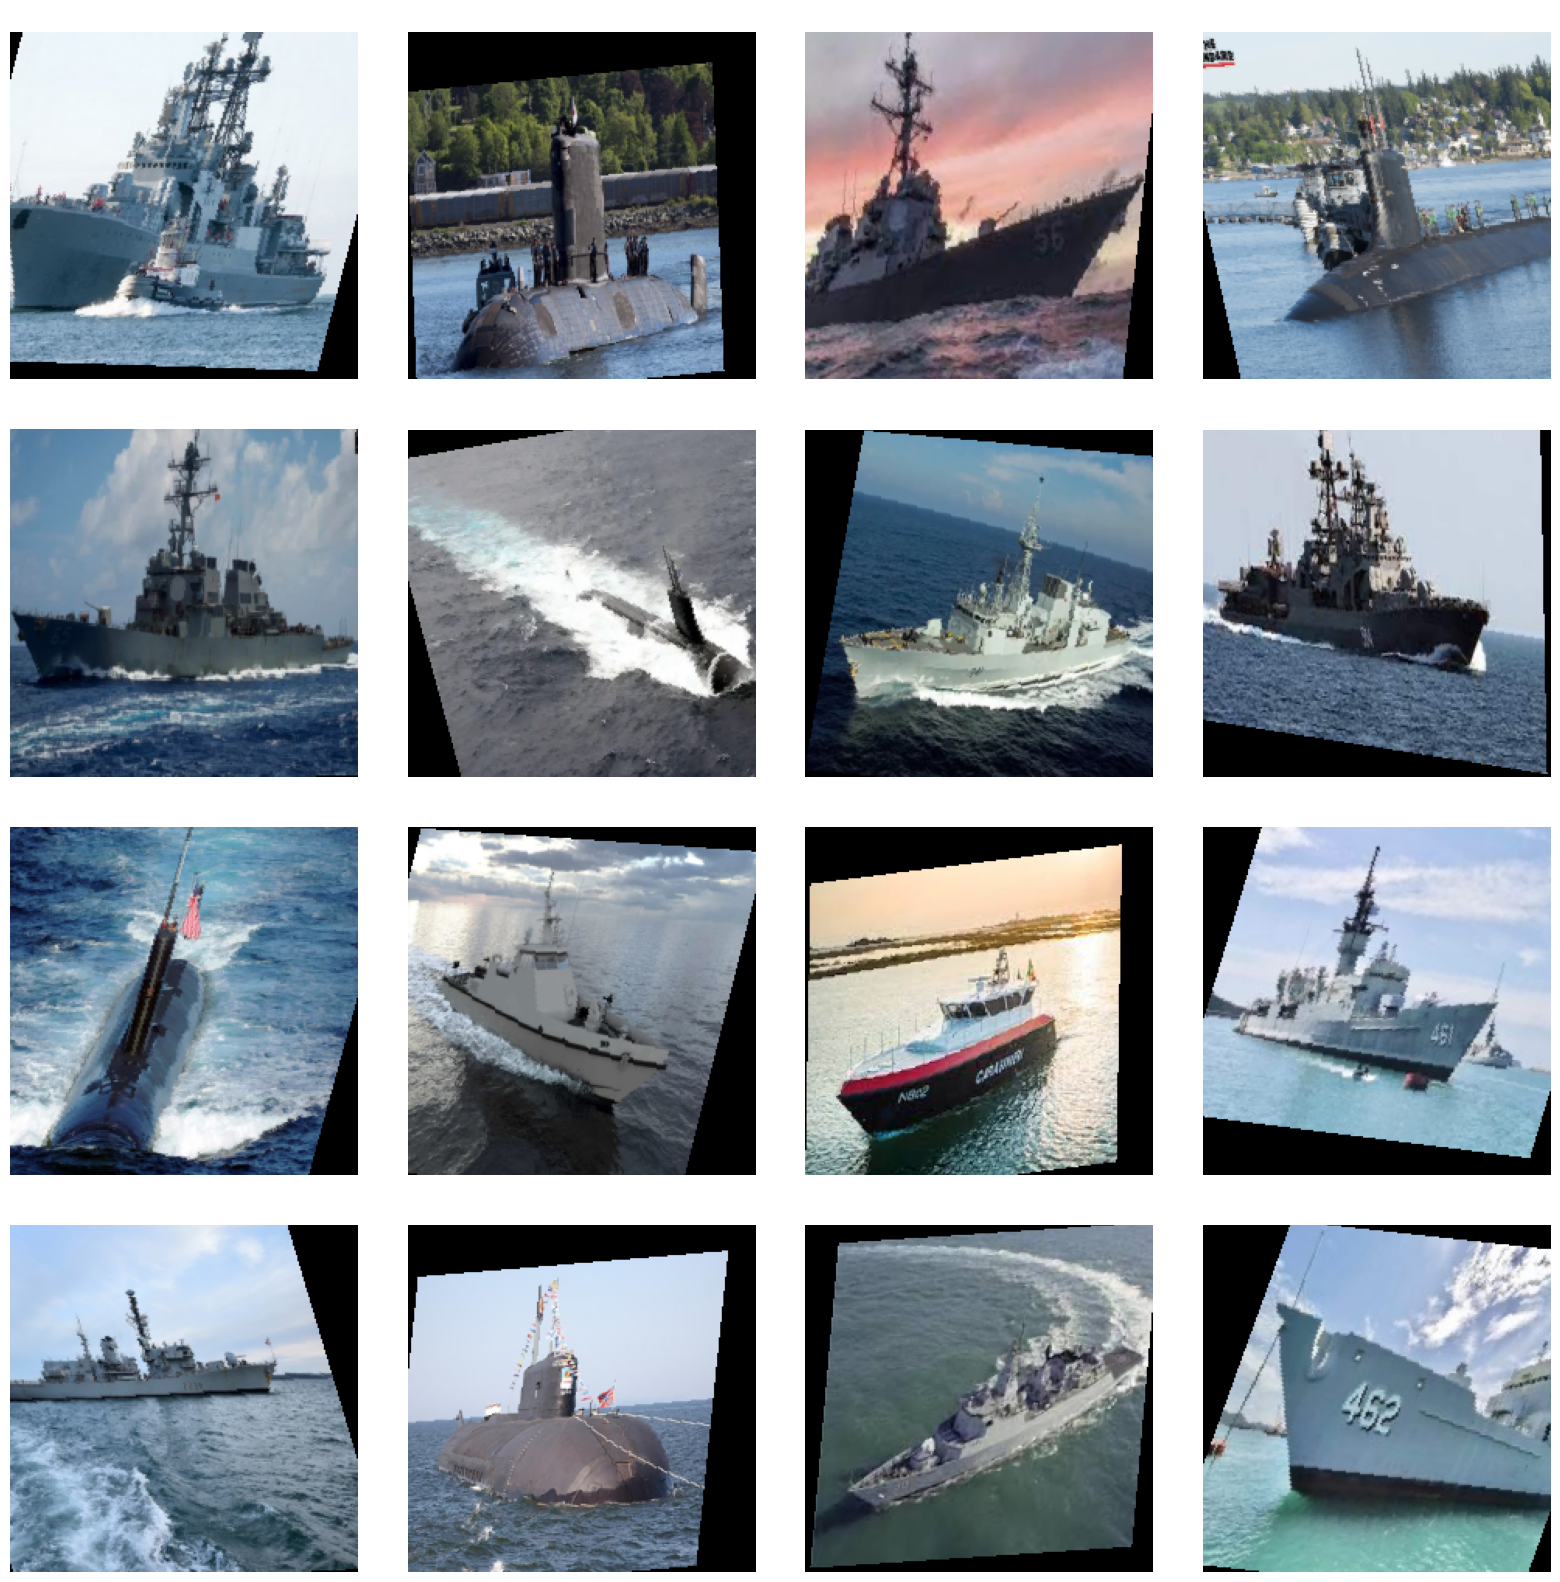

In [3]:
### START CODE HERE ###
def unzip_data(zip_path, extract_to):
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
            print(f"✅ Unzipped to: {extract_to}")
    else:
        print(f"📂 Already extracted at: {extract_to}")

unzip_data("Ship.zip", "Ship")

data_loader = load_data('./Ship/Ship/Train')

### END CODE HERE ###

Now, let's create your own `CustomImageDataset` that performs the augmentation as in the previous section, but also includes the methods `add_gaussian_blur()` and `add_gaussian_noise()`. **<font color="red">DO NOT</font>** use `transforms.Compose()`.

Resource : [CustomImageDataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html#:~:text=.show()-,Dataset%20class,-torch.utils.data)

In [ ]:
### START CODE HERE ###
class CustomImageDataset(Dataset):
    def __init__(self, image_dir, output_size=224, padding=10, apply_blur=False, apply_noise=False):
        self.image_dir = image_dir
        self.output_size = output_size
        self.apply_blur = apply_blur
        self.apply_noise = apply_noise

        self.transform_resize = transforms.Resize((224, 224))
        self.transform_tensor = transforms.ToTensor()
        self.transform_pad = transforms.Pad(padding)
        self.transform_affine = transforms.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=20)
        self.transform_crop = transforms.CenterCrop(output_size)

        # load image from subfolders (class)
        self.dataset = ImageFolder(root=self.image_dir)
        self.class_map = self.dataset.class_to_idx
        self.idx_to_class = {v: k for k, v in self.class_map.items()}

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = self.transform_resize(img)
        img = self.transform_tensor(img)
        img = self.transform_pad(img)
        img = self.transform_affine(img)
        img = self.transform_crop(img)

        if self.apply_blur:
            img = self.add_gaussian_blur(img)
        if self.apply_noise:
            img = self.add_gaussian_noise(img)

        return img, label

    def add_gaussian_blur(self, image):
        image_np = image.permute(1, 2, 0).numpy() # Convert to HWC format
        blurred = cv2.GaussianBlur(image_np, (5, 5), sigmaX=1.5)
        return torch.from_numpy(blurred).permute(2, 0, 1) 

    def add_gaussian_noise(self, image, std=0.1):
        noise = torch.randn_like(image) * std
        return torch.clamp(image + noise, 0., 1.)

    def load_data(self):
        from collections import Counter
        from mpl_toolkits.axes_grid1 import ImageGrid

        targets = [label for _, label in self.dataset]
        class_counts = Counter(targets)

        print("Class Map:", self.class_map)
        print("Class Count:", class_counts)

        data_loader = DataLoader(self, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)

        images, labels = next(iter(data_loader))

        fig = plt.figure(figsize=(20, 20))
        plt.style.use('dark_background')

        grid = ImageGrid(fig, 111, nrows_ncols=(4, 4), axes_pad=0.5)

        for ax, im, lb in zip(grid, images, labels):
            im_np = im.permute(1, 2, 0).numpy()
            ax.axis('off')
            ax.set_title(f"{lb.item()} : {self.idx_to_class[lb.item()]}")
            ax.imshow(im_np)

        plt.show()

        return data_loader
### END CODE HERE ###

Use your `CustomImageDataset()` function. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/02.png?raw=true)

</details>

Class Map: {'battleship': 0, 'patrol boat': 1, 'submarine': 2}
Class Count: Counter({0: 44, 1: 35, 2: 35})


C:\Users\USERIT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


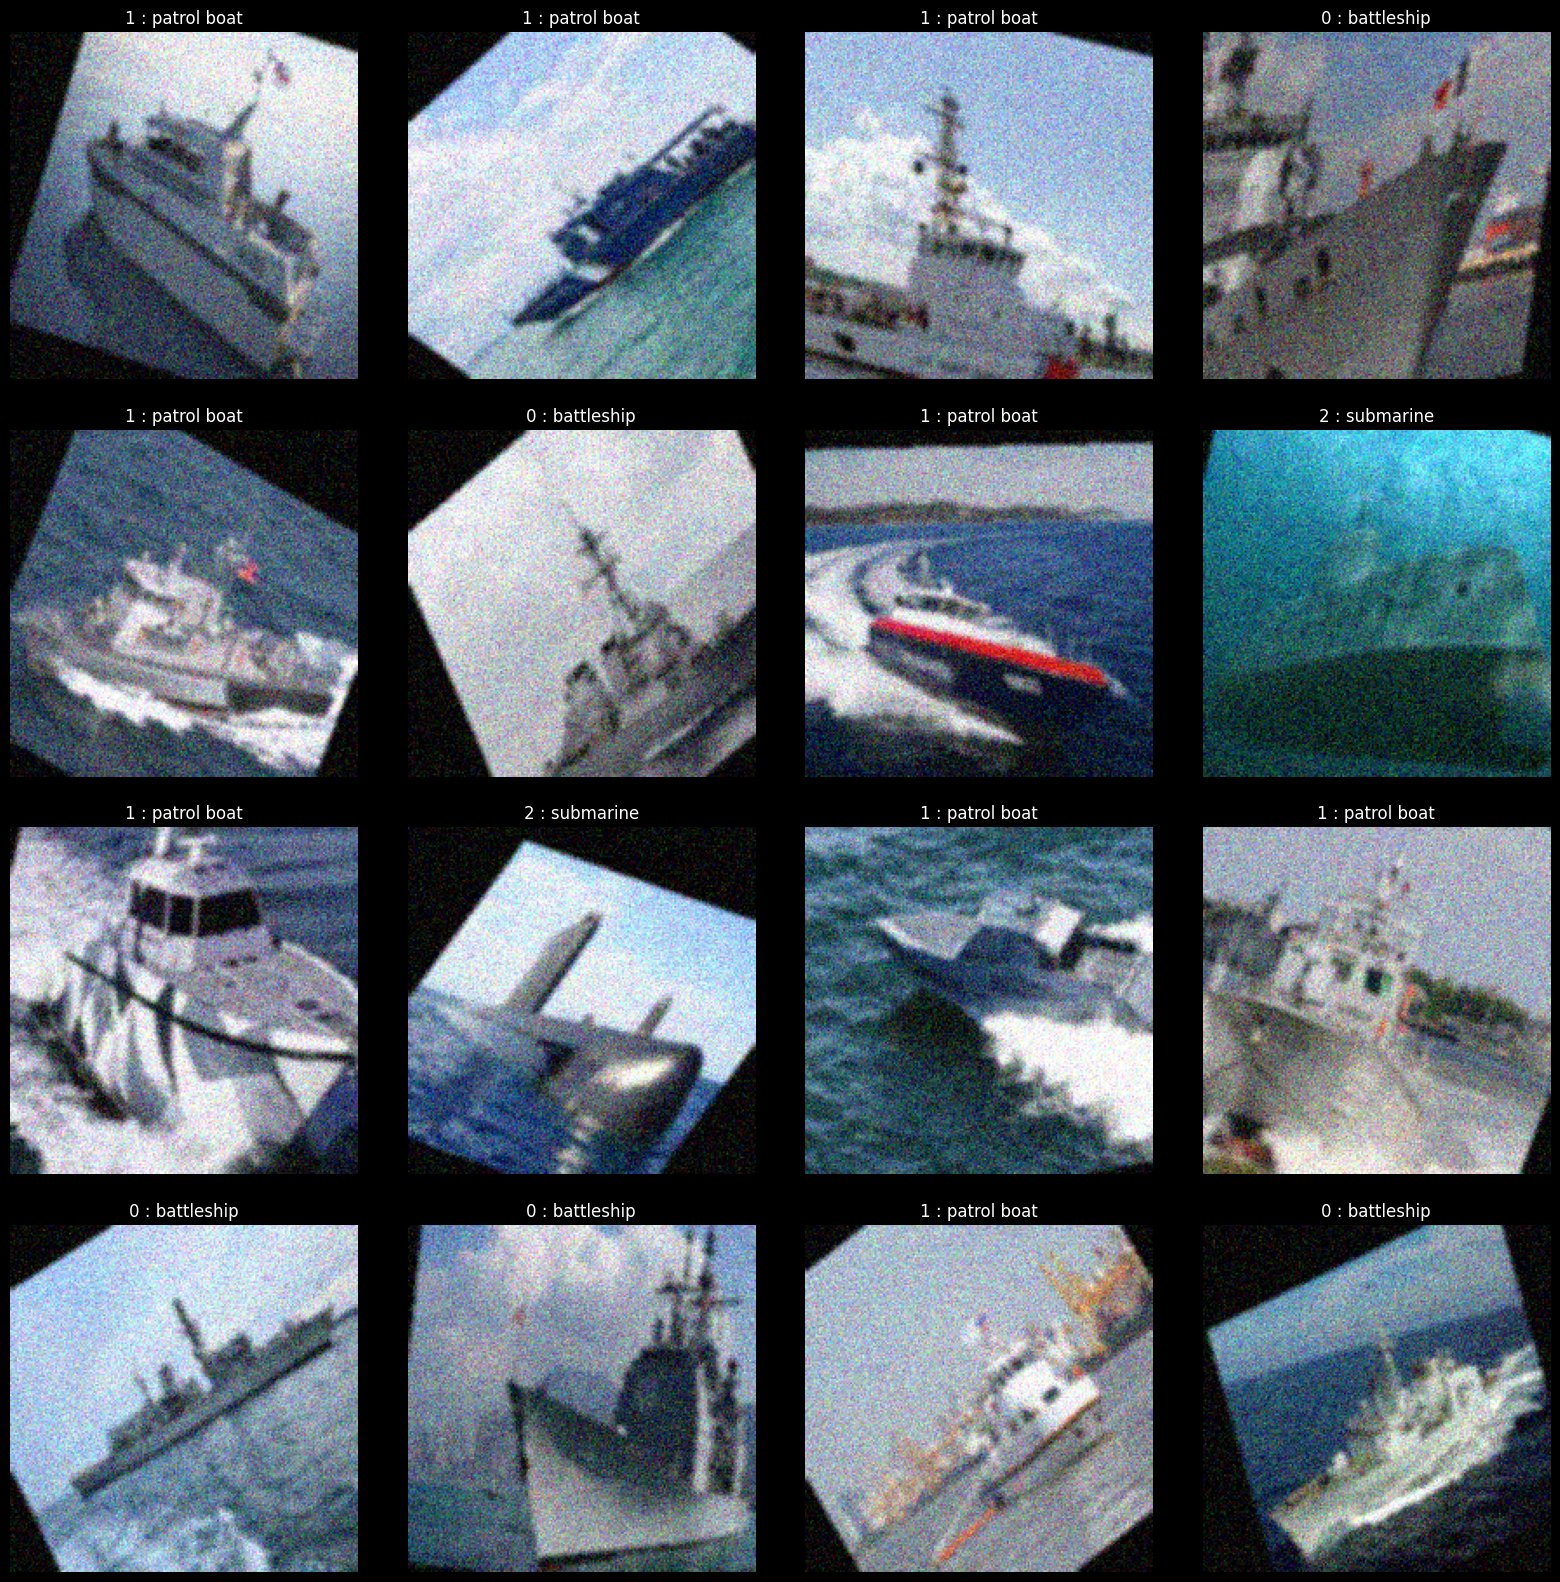

In [5]:
### START CODE HERE ###

dataset = CustomImageDataset(image_dir="./Ship/Ship/Train", output_size=200, apply_blur=True, apply_noise=True)
dataloader = dataset.load_data()

### END CODE HERE ###

Questions
1. Discuss effects and benefits of fill_mode or padding_mode.
2. What would be amount of augmentation should be so that it would not effect the training performance?
3. How can we create Salt-and-Pepper Noise, which is the type that greatly affect the image quality?
4. What would be transform parameter to simulate camera lense effect?

## Answer ##
1. การใช้ ใช้ fill_mode หรือ padding_mode ในการเติมสีที่ขอบ ช่วยป้องกันการเกิดขอบดำ และช่วยรักษาความสมจริงของภาพหลังจากทำ augmentation แต่ก็อาจสร้างข้อมูลที่ผิดธรรมชาติได้หากใช้มากเกินไป หรือใช้ไม่เหมาะกับรูปภาพ เช่น การเติมแบบ reflect หรือการที่มีพื้นที่ fill หรือ padding มากเกินไป
2. ทำ Augmentation โดยที่ยังได้ภาพที่ยังสมจริงอยู่     ไม่หมุน ซูม หรือเปลี่ยนแปลงภาพมากเกินไปจนภาพไม่สมจริง เช่น เช่น หมุนไม่เกิน ±15°, ซูมไม่เกิน ±10%, ความสว่างไม่เกิน ±20% เวลาที่ทำ Augmentation ควรทำทีละน้อยๆ แล้วค่อย ๆ เพิ่มจนกว่าผล validation จะลดลง จะได้ Data ที่ดีและไม่ส่งผลต่อประสิทธิภาพของการ train
3. เราจะสร้าง Salt-and-Pepper Noise ได้อย่างไร ซึ่งเป็นประเภทของ noise ที่ส่งผลกระทบต่อคุณภาพของภาพอย่างมาก?
•    ใช้ปริมาณ noise น้อยๆ
•    ใช้เฉพาะกับ training set 
•    ถ้าใช้ noise มาก ให้ใช้ร่วมกับ denoising filter เพื่อลดผลกระทบต่อคุณภาพของภาพ
•    ใส่ noise แบบสุ่ม แทนการใส่ทุกภาพ เช่น การใส่ noise 30% ของ training set
4. ค่าพารามิเตอร์ในการแปลง (transform parameter) อะไรที่สามารถใช้เพื่อจำลองเอฟเฟกต์ของเลนส์กล้องได้?
•    OpticalDistortion จำลองเลนส์ที่บิดเบี้ยวภาพ
•    GaussianBlur จำลองเลนส์ที่โฟกัสไม่ชัด
•    Perspective จำลองมุมกล้องที่เอียง
•    RandomBrightnessContrast จำลองแสงที่ไม่สม่ำเสมอ